# Watershed Analysis

### by Christian Oluoma

The goal of this project was to analyze digital elevation data from a set of watersheds along the western flank of the Southern Alps of New Zealand. The study focused on watersheds located in the immediate hanging wall of the Alpine Fault, where rapid tectonic uplift driven by fault motion coincides with active fluvial and glacial erosion of the landscape. One of the objectives was to examine how various calculated values differ across watersheds and what these differences reveal about the ways rivers and glaciers may have shaped the surface of each watershed. The process began with preparing the digital elevation data, followed by demonstrating how to extract data for an individual watershed, and concluded with automating the workflow and producing an interactive map that incorporates the calculated values for each watershed.

## Background

Watershed analysis involves examining the landscape and hydrology of land areas where surface water drains to a common outlet, such as a river, lake, or ocean. In this study, the focus was on understanding how factors such as watershed area and topographic relief vary across a set of river watersheds in the Southern Alps, with the aim of exploring relationships between landscape uplift and erosion. To achieve this, a series of quantitative values were calculated for each watershed and subsequently analyzed to assess spatial variability within the study area. The analysis required several steps, including loading digital elevation data for the region, delineating the watersheds of interest, evaluating the landscape characteristics of each watershed, and visualizing the results. The following sections provide a detailed examination of these processes and demonstrate how watershed analysis can be performed using Python.

## Methodology

Watershed delineation involves identifying all points that lie upstream (or upslope) of a specified outlet on a digital elevation model (DEM). Outlet points can be determined in various ways; in this case study, they were selected visually using Google Maps by identifying locations where rivers along the western side of the New Zealand Alps, between approximately 42.4°S and 44.0°S, exit their valleys. This latitude range roughly corresponds to a linear segment of the Alpine Fault, which forms the boundary between the Australian and Pacific tectonic plates.

After outlet points are identified, several preprocessing steps are required to ensure that watersheds can be accurately defined. Specifically, the DEM must be conditioned so that water flow paths can be determined, assuming that water moves to neighboring cells of lower elevation. This initial preprocessing is collectively referred to as hydrological conditioning and includes the following steps:

`Filling pits:` Pits are individual cells in the DEM with no neighboring cell at a lower elevation. Their elevations must be increased so that water can flow toward at least one neighboring cell.

`Filling depressions:` Depressions are groups of cells lacking an outlet. Their elevations must similarly be adjusted to allow drainage to a downstream cell.

`Resolving flats:` In flat regions, such as lakes, water cannot flow downhill. These areas must be modified to establish a continuous flow path toward the outlet.

Once the DEM has been conditioned, additional steps are performed using the updated DEM to generate the necessary information for watershed delineation:

`Determining flow directions:` This step identifies the direction in which water would flow from each DEM cell, enabling tracing upstream from the outlet to delineate watershed boundaries.

`Determining flow accumulation:`Flow accumulation calculates the number of upstream cells draining into each DEM cell. While not strictly required for watershed delineation, it can assist in identifying river channels, especially when outlet points are not located precisely on a channel cell.

Following these procedures, it becomes possible to delineate the watershed upstream of the specified outlet point accurately.

In [1]:
# Import required libraries

#from basin_functions import *
from geocube.vector import vectorize
import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from pysheds.grid import Grid
from pysheds.view import Raster, ViewFinder
import rioxarray as rxr
import xarray as xr

In [2]:
# Set plotting style

plt.style.use("bmh")

In [3]:
# Read the data

# S3 bucket containing the data
bucket_home = "https://a3s.fi/swift/v1/AUTH_0914d8aff9684df589041a759b549fc2/PythonGIS/"
bucket_dem_file = "elevation/new_zealand/south_island_nz.tif"
bucket_dem_fp = bucket_home + bucket_dem_file

# Read the input data file
south_island = rxr.open_rasterio(bucket_dem_fp).drop_vars("band")[0]

In [4]:
# Inspect the data

south_island

<xarray.DataArray (y: 10800, x: 18000)> Size: 778MB
[194400000 values with dtype=float32]
Coordinates:
  * x            (x) float64 144kB 167.5 167.5 167.5 167.5 ... 172.5 172.5 172.5
  * y            (y) float64 86kB -41.8 -41.8 -41.8 -41.8 ... -44.8 -44.8 -44.8
    spatial_ref  int32 4B 0
Attributes:
    TIFFTAG_IMAGEDESCRIPTION:  Product Version 4.1
    TIFFTAG_XRESOLUTION:       1
    TIFFTAG_YRESOLUTION:       1
    AREA_OR_POINT:             Area
    scale_factor:              1.0
    add_offset:                0.0
    long_name:                 elevation

In [5]:
# Read the DEM into pysheds

data = south_island.data
affine = south_island.rio.transform()
crs = south_island.rio.crs

# Keep same data type as DEM values for nodata
nodata = data.dtype.type(-9999)

viewfinder = ViewFinder(affine=affine, shape=data.shape, crs=crs, nodata=nodata)
dem = Raster(data, viewfinder=viewfinder)

# Create grid
grid = Grid.from_raster(dem)

Number of pits found: 621219


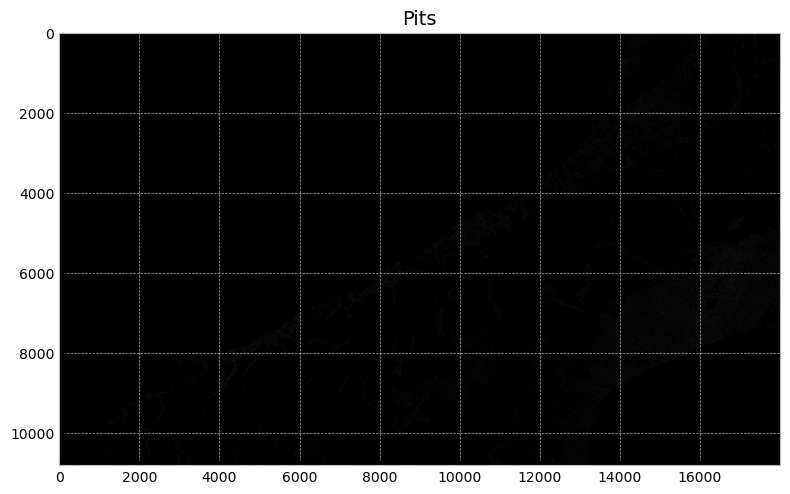

In [6]:
# Prepare the DEM for analysis in pysheds

checkpoint = True
if checkpoint:
    # Create checkpoint_data directory if it does not exist
    wd = Path.cwd()
    newdir = wd / "checkpoint_data"
    newdir.mkdir(parents=True, exist_ok=True)

# Detect number of pits in DEM
pits = grid.detect_pits(dem)
npits = np.count_nonzero(pits)

# Check number of pits
print(f"Number of pits found: {npits}")

# Plot pits if more than zero
if npits > 0:
    # Plot pits
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_alpha(0)

    plt.imshow(pits, cmap="Greys_r", zorder=1)
    plt.title("Pits", size=14)
    plt.tight_layout()

# Fill pits and check they have been filled
pit_filled_dem = grid.fill_pits(dem)
pits = grid.detect_pits(pit_filled_dem)
assert not pits.any()

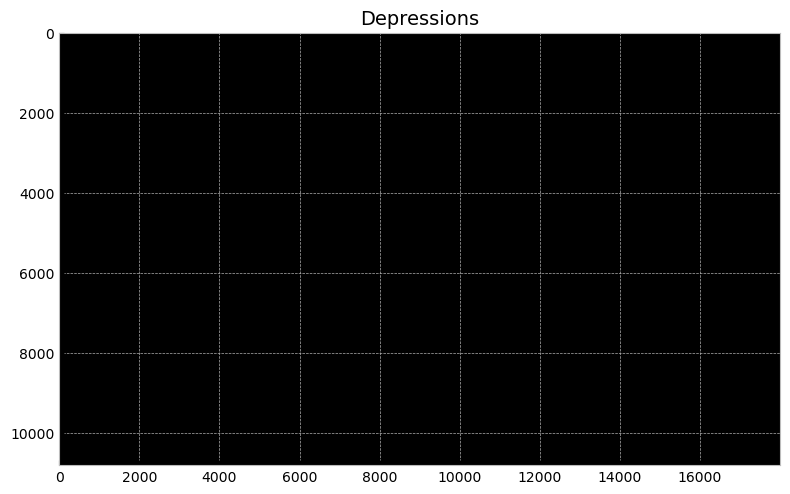

In [7]:
# Detect depressions - Slow. May take 5 minutes or more.

depressions = grid.detect_depressions(pit_filled_dem)

# Plot depressions - in case you would like to do so with other DEMs
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

plt.imshow(depressions, cmap="Greys_r", zorder=1)
plt.title("Depressions", size=14)
plt.tight_layout()

In [8]:
# Write the output to a file

if checkpoint:
    # Write dataset to file
    grid.to_raster(
        pit_filled_dem,
        "checkpoint_data/pit_filled_dem.tif",
        blockxsize=16,
        blockysize=16,
    )
    
    grid.to_raster(
        depressions,
        "checkpoint_data/detected_depressions.tif",
        dtype=int,             # used to avoid write error for boolean values
        blockxsize=16,
        blockysize=16,
    )

continue_from_here = False
if continue_from_here:
    grid, pit_filled_dem = continue_pysheds("checkpoint_data/pit_filled_dem.tif")
    _, depressions = continue_pysheds("checkpoint_data/detected_depressions.tif")

In [9]:
# Fill depressions - Slow, takes 5-10 minutes...

flooded_dem = grid.fill_depressions(pit_filled_dem)
depressions = grid.detect_depressions(flooded_dem)
assert not depressions.any()

if checkpoint:
    # Write dataset to file
    grid.to_raster(
        flooded_dem, "checkpoint_data/flooded_dem.tif", blockxsize=16, blockysize=16
    )

continue_from_here = False
if continue_from_here:
    grid, pit_filled_dem = continue_pysheds("checkpoint_data/pit_filled_dem.tif")
    _, depressions = continue_pysheds("checkpoint_data/detected_depressions.tif")
    _, flooded_dem = continue_pysheds("checkpoint_data/flooded_dem.tif")

Number of flats found: 154984111


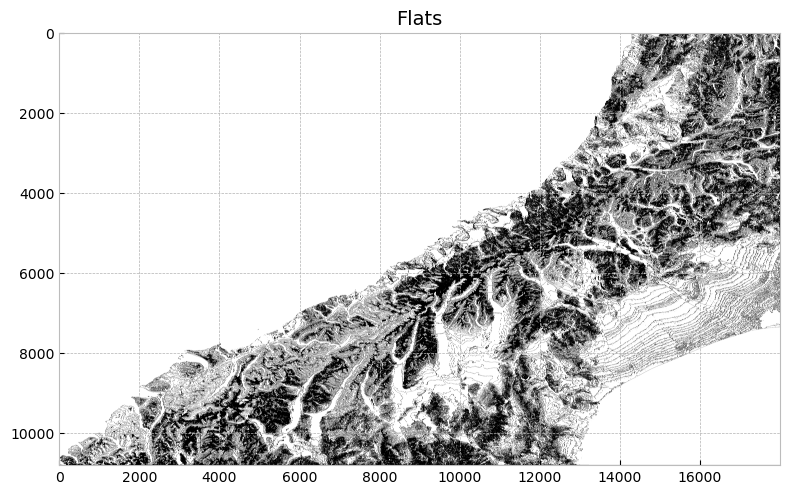

In [10]:
# Detect flats

flats = grid.detect_flats(flooded_dem)
nflats = np.count_nonzero(flats)

# Check number of flats
print(f"Number of flats found: {nflats}")

# Plot flats
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

plt.imshow(flats, cmap="Greys_r", zorder=1)
plt.title("Flats", size=14)
plt.tight_layout()

# Resolve flats
inflated_dem = grid.resolve_flats(flooded_dem)

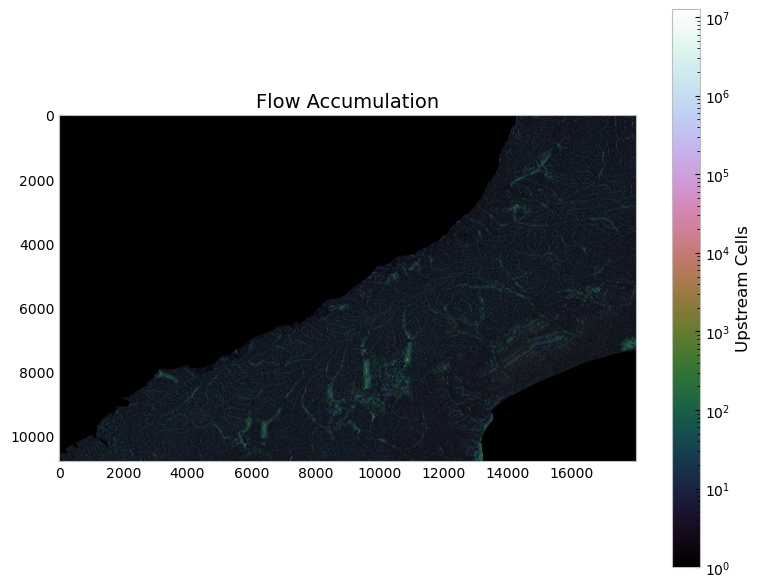

In [11]:
# Calculate values related to surface water flows

# Compute flow direction based on corrected DEM (D8)
fdir = grid.flowdir(inflated_dem)

# Compute flow accumulation based on computed flow direction
acc = grid.accumulation(fdir)

# Plot flow accumulation, if requested
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
im = ax.imshow(
    acc,
    zorder=2,
    cmap="cubehelix",
    norm=colors.LogNorm(1, acc.max()),
    interpolation="bilinear",
)
plt.colorbar(im, ax=ax, label="Upstream Cells")
plt.title("Flow Accumulation", size=14)
plt.tight_layout()

In [12]:
if checkpoint:
    # Write flow accumulation and directions to file
    grid.to_raster(
        acc, "checkpoint_data/flow_accumulation.tif", blockxsize=16, blockysize=16
    )
    grid.to_raster(
        fdir, "checkpoint_data/flow_directions.tif", blockxsize=16, blockysize=16
    )
    
continue_from_here = False
if continue_from_here:
    grid, pit_filled_dem = continue_pysheds("checkpoint_data/pit_filled_dem.tif")
    _, depressions = continue_pysheds("checkpoint_data/detected_depressions.tif")
    _, flooded_dem = continue_pysheds("checkpoint_data/flooded_dem.tif")
    _, acc = continue_pysheds("checkpoint_data/flow_accumulation.tif")
    _, fdir = continue_pysheds("checkpoint_data/flow_directions.tif")

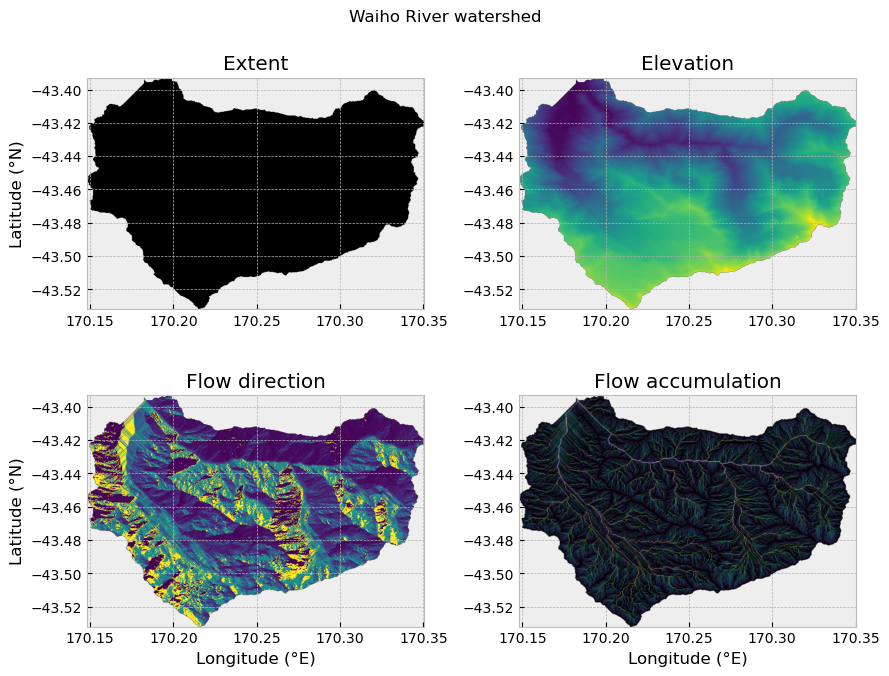

In [13]:
# Define and extract a watershed

outlet = (170.182282, -43.394347)
# Snap outlet point to nearby cell with high flow accumulation
x_snap, y_snap = grid.snap_to_mask(acc > 1000, outlet)

# Delineate the watershed
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, xytype="coordinate")

# Clip and set view extents
grid.clip_to(catch)
catch_view = grid.view(catch, nodata=np.nan)
fdir_view = grid.view(fdir, nodata=np.nan)
acc_view = grid.view(acc, nodata=np.nan)
dem_view = grid.view(dem, nodata=np.nan)

# Create figure and plot axes
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
fig.patch.set_alpha(0)

# Plot watershed extent
im = axes[0, 0].imshow(catch_view, extent=grid.extent, zorder=1, cmap="Greys_r")
axes[0, 0].set_title("Extent")
axes[0, 0].set_ylabel("Latitude (°N)")

# Plot watershed elevations
im = axes[0, 1].imshow(dem_view, extent=grid.extent, zorder=1, cmap="viridis")
axes[0, 1].set_title("Elevation")

# Plot watershed flow directions
im = axes[1, 0].imshow(fdir_view, extent=grid.extent, zorder=1, cmap="viridis")
axes[1, 0].set_title("Flow direction")
axes[1, 0].set_xlabel("Longitude (°E)")
axes[1, 0].set_ylabel("Latitude (°N)")

# Plot watershed flow accumulation
im = axes[1, 1].imshow(
    acc_view,
    extent=grid.extent,
    zorder=2,
    cmap="cubehelix",
    norm=colors.LogNorm(1, acc.max()),
    interpolation="bilinear",
)
axes[1, 1].set_title("Flow accumulation")
axes[1, 1].set_xlabel("Longitude (°E)")

# Add a figure title
plt.suptitle("Waiho River watershed")
plt.tight_layout()

In [ ]:
# Analyze the watershed data

# Compute distance to outlet
dist = grid.distance_to_outlet(
    x=x_snap,
    y=y_snap,
    fdir=fdir,
    xytype="coordinate",
)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

# Plot distance to outlet
im = ax.imshow(dist, extent=grid.extent, zorder=2, cmap="cividis_r")

# Add colorbar, axis labels, and a title
plt.colorbar(im, ax=ax, label="Distance to outlet (cells)")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Distance to outlet", size=14)

In [ ]:
# Extract river network
branches = grid.extract_river_network(fdir, acc > 100)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot channel segments
for branch in branches["features"]:
    line = np.asarray(branch["geometry"]["coordinates"])
    plt.plot(line[:, 0], line[:, 1])

# Add axis labels and title
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Channel network (>100 accumulation)", size=14);

In [ ]:
# Export the watershed data to xarray

# Convert watershed data for xarray
catchment = dem_view
data = catchment.data

# Get latitude and longitude ranges
lat = np.unique(catchment.coords[:, 0])
# Get latitude points in correct order (reverse order of array values)
lat = np.flip(lat)
lon = np.unique(catchment.coords[:, 1])

# Create DataArray
catch_xr = xr.DataArray(catchment.base, coords={"y": lat, "x": lon}, dims=["y", "x"])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

catch_xr.plot(ax=ax, cmap="plasma", cbar_kwargs={"label": "Elevation (m)"})
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("Waiho River data in xarray");

In [ ]:
# Calculate basin hypsometry

catchment_elevations = catch_xr.values[~np.isnan(catch_xr.values)]
nbins = 20
counts, bins = np.histogram(catchment_elevations, bins=nbins)

# Create figure and axis
fig, ax = plt.subplots(1, 1)

# Plot elevation histogram
ax.hist(catchment_elevations, bins=nbins)

# Add axis labels
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Number of occurences")
plt.tight_layout()

In [ ]:
# Define bin elevation range
binsize = 50.0

# Determine the bounds for the minimum and maximum bins
minbin = catchment_elevations.min() - catchment_elevations.min() % +binsize
maxbin = catchment_elevations.max() - catchment_elevations.max() % -binsize

# Calculate number of bins and histogram
nbins = np.arange(minbin, maxbin + 1.0, binsize)
counts, bins = np.histogram(catchment_elevations, bins=nbins)

# Create figure and axis
fig, ax = plt.subplots(1, 1)

# Plot elevation histogram
ax.hist(catchment_elevations, bins=nbins)

# Add axis labels
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Number of occurences")
plt.tight_layout()

In [ ]:
# Calculate (normalized) cumulative distribution
norm_counts = counts.cumsum() / counts.cumsum().max()

# Convert to area above min elevation
norm_counts = 1 - norm_counts

# Normalize elevation ranges
norm_bins = (bins - bins.min()) / (bins.max() - bins.min())

# Calculate hypsometric integral
bin_width = norm_bins[1] - norm_bins[0]
hyps_integral = sum(norm_counts * bin_width)
print(f"Hypsometric integral: {abs(hyps_integral):.3f}")

In [ ]:
# plot the hypsometric curve
fig, ax = plt.subplots(1, 1)
# ax.plot(bins[:-1], counts, "k+")
ax.plot(norm_counts, bins[:-1], "r", label="Basin hypsometric curve")
ax.set_xlabel("Area fraction above elevation")
ax.set_ylabel("Elevation (m)")
ax.plot(
    [0.0, 1.0],
    [bins[:-1].max(), bins[:-1].min()],
    "--",
    color="gray",
    label="Linear reference (HI = 0.5)",
)
ax.legend()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(bins[:-1].min(), bins[:-1].max())
ax.text(
    0.05,
    (0.05 * bins[:-1].max()) + bins[:-1].min(),
    f"Hypsometric integral: {abs(hyps_integral):.3f}",
);

### Automate the Process

1. Set the grid extent to the extent of the full DEM
2. Snap the pour point to the nearest high-discharge cell
3. Delineate the watershed
4. Set the grid extent to that of the delineated watershed
5. Export the watershed data to xarray
6. Store the watershed elevations without the nan values and calculate the hypsometric integral
7. Extract a vector boundary of the watershed for plotting
8. Store the watershed data in the lists created



In [ ]:
river_names = [
    "Arawhata River",
    "Waiatoto River",
    "Turnbull River",
    "Okuru River",
    "Haast River",
    "Moeraki River",
    "Paringa River",
    "Mahitahi River",
    "Jacobs River",
    "Karangarua River",
    "Cook River",
    "Fox River",
    "Waikukupa River",
    "Omoeroa River",
    "Waiho River",
    "Waitangitaona River",
    "Darnley Creek",
    "Whataroa River",
    "Poerua River",
    "Wanganui River",
    "Waitaha River",
    "Kakapotahi River?",
    "Mikonui River",
    "Hokitika River",
    "Toaroha River",
    "Kokatahi River",
    "Styx River",
    "Arahura River",
    "Taipo River",
    "Taramakau River",
    "Crooked River",
    "Evans River",
    "Haupiri River",
    "Waikiti River",
    "Tutaekuri River",
    "Waiheke River",
    "Robinson River",
    "Blue Grey River",
]

# For each river or creek we have a corresponding outlet location or pour point (pour_points).

pour_points = [
    (168.723432, -44.060960),
    (168.838838, -44.023259),
    (168.942363, -43.971371),
    (168.987365, -43.952888),
    (169.144604, -43.935653),
    (169.351885, -43.785118),
    (169.497063, -43.716472),
    (169.593608, -43.666203),
    (169.695061, -43.617701),
    (169.808933, -43.576726),
    (169.965037, -43.498121),
    (170.008772, -43.478192),
    (170.070511, -43.443732),
    (170.102720, -43.425248),
    (170.182282, -43.394347),
    (170.274318, -43.343211),
    (170.302801, -43.326779),
    (170.403417, -43.285756),
    (170.525003, -43.217547),
    (170.624160, -43.158141),
    (170.729994, -43.107470),
    (170.820316, -43.064461),
    (170.869467, -43.014418),
    (171.012521, -42.957962),
    (171.131477, -42.910875),
    (171.150106, -42.903147),
    (171.165837, -42.884519),
    (171.238172, -42.840905),
    (171.405012, -42.755411),
    (171.467475, -42.733149),
    (171.626527, -42.649998),
    (171.682798, -42.618596),
    (171.733798, -42.612758),
    (171.886492, -42.568796),
    (171.979749, -42.559885),
    (171.995805, -42.546945),
    (172.012893, -42.471985),
    (172.136101, -42.411857),
]

In [ ]:
# Create empty lists for storing outputs
catchment_numbers = []
catchment_lons = []
catchment_lats = []
catchment_areas = []
catchment_min_elevs = []
catchment_max_elevs = []
catchment_reliefs = []
catchment_his = []
catchment_boundaries = []

# Initialize catchment number for batch processing
catchment_number = 0

In [ ]:
print("Processing watersheds", end="")

for i in range(len(pour_points)):
    # Print a progress dot and increment catchment number
    print(".", end="", flush=True)
    catchment_number = i + 1

    # Reset grid extent
    grid.clip_to(dem)

    # Delineate the watershed
    x_snap, y_snap = grid.snap_to_mask(acc > 1000, pour_points[i])
    current_catchment = grid.catchment(
        x=x_snap, y=y_snap, fdir=fdir, xytype="coordinate"
    )

    # Clip and set view extent
    grid.clip_to(current_catchment)
    dem_view = grid.view(dem, nodata=np.nan)

    # Save watershed elevations in xarray
    catchment = dem_view
    data = catchment.data
    lat = np.unique(catchment.coords[:, 0])
    lat = np.flip(lat)
    lon = np.unique(catchment.coords[:, 1])
    catch_xr = xr.DataArray(
        catchment.base, coords={"y": lat, "x": lon}, dims=["y", "x"]
    )

    # Store elevations minus NaN values, calculate elevation histogram
    # and hypsometric integral
    catch_elev = catch_xr.values[~np.isnan(catch_xr.values)]
    counts, bins = calculate_hypsometry(catch_elev)
    hyps_integral = calculate_hypsometric_integral(counts, bins)

    # Extract vector boundary of watershed
    catch_xr.name = f"Watershed {catchment_number}"
    catch_gdf = vectorize(catch_xr.astype("float32"))
    catch_gdf = catch_gdf.dropna(subset=f"Watershed {catchment_number}")
    catch_gdf = catch_gdf.set_crs("epsg:4326")
    dissolved = catch_gdf.dissolve(method="unary")
    dissolved = dissolved.rename(columns={"geometry": "basin_boundary"})

    # Append watershed info to lists
    catchment_numbers.append(catchment_number)
    catchment_lons.append(pour_points[i][0])
    catchment_lats.append(pour_points[i][1])
    catchment_areas.append(round(calculate_area(catch_elev), 1))
    catchment_min_elevs.append(catch_elev.min())
    catchment_max_elevs.append(catch_elev.max())
    catchment_reliefs.append(calculate_relief(catch_elev))
    catchment_his.append(round(hyps_integral, 3))
    catchment_boundaries.append(dissolved["basin_boundary"].values[0])

print("done.")

In [ ]:
# Plot the result

data = {
    "Watershed number": catchment_numbers,
    "River name": river_names,
    "Outlet longitude (deg.)": catchment_lons,
    "Outlet latitude (deg.)": catchment_lats,
    "Area (sq. km)": catchment_areas,
    "Min. elevation (m)": catchment_min_elevs,
    "Max. elevation (m)": catchment_max_elevs,
    "Relief (m)": catchment_reliefs,
    "Hypsometric integral": catchment_his,
    "Basin boundary": catchment_boundaries,
}

catchment_df = pd.DataFrame(data)
catchment_df.head()

In [ ]:
# create a geopandas GeoDataFrame from the catchment_df DataFrame

catchment_df["geometry"] = gpd.points_from_xy(
    x=catchment_df["Outlet longitude (deg.)"], y=catchment_df["Outlet latitude (deg.)"]
)

catchment_gdf = gpd.GeoDataFrame(catchment_df, crs="epsg:4326")

# Read fault data from Geopackage
bucket_fault_file = "features/new_zealand/alpine_fault.gpkg"
bucket_fault_fp = bucket_home + bucket_fault_file

fault_df = gpd.read_file(bucket_fault_fp)

In [ ]:
# Plot Alpine Fault
m = fault_df.loc[fault_df["name"] == "Alpine Fault"].explore(
    column="name", cmap="gist_gray"
)

# Set active geometry layer and plot watersheds
catchment_gdf["Points"] = catchment_gdf["geometry"]
catchment_gdf = catchment_gdf.set_geometry("Basin boundary")
basin_color_field = "Hypsometric integral"
m = catchment_gdf.explore(
    m=m,
    column=basin_color_field,
    cmap="plasma",
)

# Set active geometry layer and plot outlet points
catchment_gdf = catchment_gdf.set_geometry("Points")
m = catchment_gdf.explore(m=m, color="black", marker_kwds={"radius": 2})
m

## Conclusion

First, in terms of the output produced, let's take a moment to observe a few things. First, the values of the hypsometric integral range from 0.33 to 0.54. Although the exact values of the hypsometric integral should be interpreted carefully, a lower value of the hypsometric integral is associated with more removal of mass from a watershed by erosional processes, and often lower values within a given region reflect a larger impact of glacial erosion on the landscape (e.g., Sternai et al., 2011). Within the study region, we can observe that, in general, the values of the hypsometric integral decrease towards the southwest towards the heavily glaciated landscapes of the Fiordland National Park.

We can confirm this trend by looking at a plot of the hypsometric integral as a function of latitude.

In [ ]:
catchment_df.plot(
    x="Outlet latitude (deg.)", y="Hypsometric integral", kind="scatter", color="black"
);

Although there is a relationship between the hypsometric integral values and latitude, the correlation appears rather weak (feel free to confirm by your own regression analysis!).

Second, it is clear that smaller watersheds generally have higher hypsometric integral values. This relationship is perhaps not a huge surprise in the rapidly uplifted landscape of the Southern Alps, where smaller watersheds have less power for erosion due to less total discharge in the rivers. Thus, the uplift of the landscape may outpace the river’s erosion, resulting in a higher hypsometric integral value in small watersheds.

Again, if we look at this in a scatter plot we can clearly see the relationship between the watershed area and the hypsometric integral. In this case the correlation is stronger than that observed for latitude.

In [ ]:
catchment_df.plot(
    x="Area (sq. km)", y="Hypsometric integral", kind="scatter", color="black"
);

### Thank You